# PARTE 1 – FILTROS

## a. Filtro de Media

### Definición

El filtro de media, también conocido como filtro promedio (Mean Filter), es un filtro lineal que reemplaza el valor de un píxel por el promedio de los valores de los píxeles en una vecindad alrededor de él.

Su principal función es suavizar la imagen y disminuir ruido aleatorio.

### Fórmula Matemática
El nuevo valor del píxel se calcula como:

$$g(x,y) = \frac{1}{mn} \sum_{i=-a}^{a} \sum_{j=-b}^{b} f(x+i, y+j)$$

Donde:
* $f(x,y)$: valor original del píxel
* $g(x,y)$: nuevo valor filtrado
* $m \times n$: tamaño de la ventana (por ejemplo 3x3)

### Ejemplo Manual (una iteración)
Supongamos esta vecindad 3x3 tomada de una imagen con ruido:

$$\begin{bmatrix} 52 & 55 & 54 \\ 53 & 200 & 52 \\ 54 & 53 & 55 \end{bmatrix}$$

Queremos calcular el nuevo valor del píxel central (200).

Aplicamos el promedio:

$$\frac{52 + 55 + 54 + 53 + 200 + 52 + 54 + 53 + 55}{9}$$

$$\frac{628}{9} = 69.78$$

Aproximando:

$$70$$

Entonces el píxel central cambia de:

$$200 \rightarrow 70$$

Nueva vecindad:

$$\begin{bmatrix} 52 & 55 & 54 \\ 53 & 70 & 52 \\ 54 & 53 & 55 \end{bmatrix}$$

### Explicación del ejemplo
El valor **200** era un valor atípico (ruido).

El filtro de media lo reemplaza por un valor más cercano a sus vecinos, suavizando la región y reduciendo ese ruido.

**Visualmente:**
* Elimina pequeñas variaciones.
* Suaviza detalles.
* Reduce ruido.

---

### Ventajas y Desventajas

**Ventajas:**
* Fácil de implementar.
* Bajo costo computacional.
* Reduce ruido aleatorio.
* Suaviza imágenes rápidamente.

**Desventajas:**
* Difumina bordes.
* Puede perder detalles finos.
* No es muy bueno para ruido impulsivo (sal y pimienta).
* Todos los píxeles tienen igual peso, incluso valores ruidosos.

---

### ¿Qué hace visualmente en la imagen?

**Antes:**
* Imagen más ruidosa.
* Bordes menos suaves.

**Después:**
* Apariencia más uniforme.
* Menos ruido.
* Algo de desenfoque.

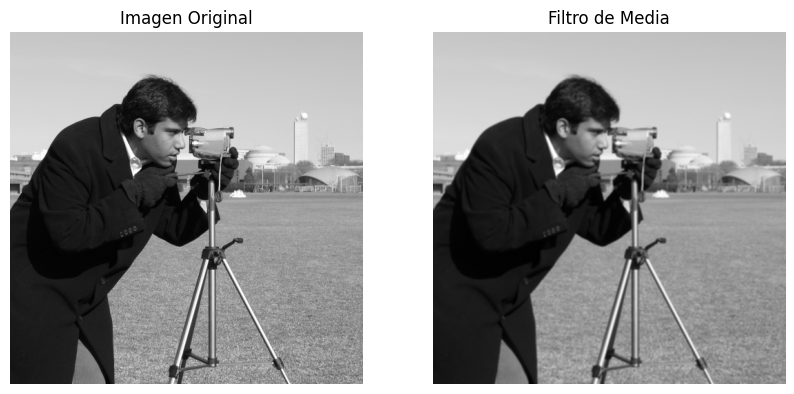

In [1]:
import cv2
import matplotlib.pyplot as plt
from skimage import data

# Imagen estándar
img = data.camera()

# Filtro de media 3x3
media = cv2.blur(img,(3,3))

# Mostrar resultados
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(media,cmap='gray')
plt.title('Filtro de Media')
plt.axis('off')

plt.show()

### Conclusión del filtro

El filtro de media es una técnica básica de suavizado que reduce ruido mediante el promedio de intensidades vecinas. Aunque puede difuminar bordes, es útil como primer paso de preprocesamiento en muchas aplicaciones de procesamiento digital de imágenes.

## b. Filtro de Mediana

### Definición

El filtro de mediana es un filtro no lineal que reemplaza el valor de un píxel por la mediana de los valores dentro de una vecindad.

La mediana es el valor que queda en el centro después de ordenar los datos.

Su uso principal es eliminar ruido impulsivo (ruido sal y pimienta).

### Fórmula Matemática
El nuevo píxel se calcula como:

$$g(x, y) = \text{Mediana}\{f(x+i, y+j)\}$$

Tomando todos los valores de la vecindad.

### Ejemplo Manual (una iteración)
Supongamos la siguiente región de una imagen:

$$\begin{bmatrix} 10 & 12 & 11 \\ 13 & 255 & 14 \\ 12 & 13 & 11 \end{bmatrix}$$

El valor **255** representa ruido impulsivo.

Ordenamos los valores:

$$10, 11, 11, 12, 12, 13, 13, 14, 255$$

Como hay 9 valores, la mediana es el quinto valor:

$$12$$

Entonces el píxel central cambia:

$$255 \rightarrow 12$$

Nueva región:

$$\begin{bmatrix} 10 & 12 & 11 \\ 13 & 12 & 14 \\ 12 & 13 & 11 \end{bmatrix}$$

### Explicación del ejemplo
El valor **255** era un valor atípico causado por ruido.

En lugar de promediarlo, el filtro lo reemplaza por la **mediana** de sus vecinos, eliminando el ruido sin alterar demasiado los bordes.

---

### Ventajas y Desventajas

**Ventajas:**
* Conserva bordes mejor que el filtro de media.
* No se afecta tanto por valores extremos.
* Reduce ruido sin generar mucho desenfoque.

**Desventajas:**
* Más costoso que el filtro de media (requiere ordenar los valores).
* Puede eliminar detalles pequeños.
* Menos efectivo para ruido gaussiano.
* Es no lineal, por lo que su análisis es más complejo.

---

### ¿Qué hace visualmente en la imagen?

**Antes:**
* Aparecen puntos aislados de ruido.

**Después:**
* Se eliminan esos puntos aislados.
* Los bordes se conservan mejor que con otros filtros.
* La imagen queda más limpia y nítida.

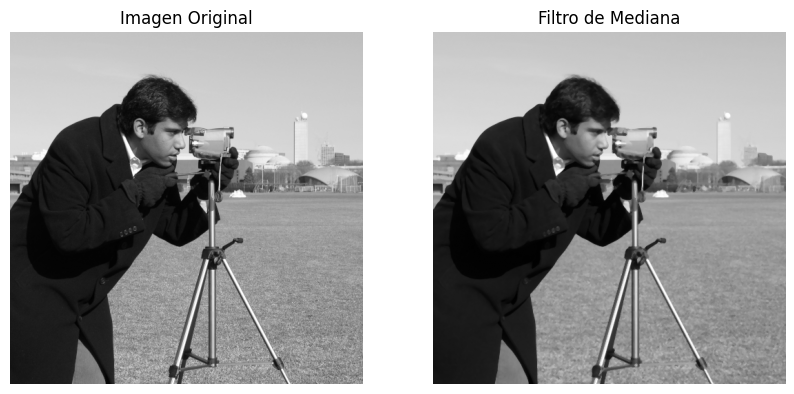

In [2]:
import cv2
import matplotlib.pyplot as plt
from skimage import data

img = data.camera()

mediana = cv2.medianBlur(img,3)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(mediana,cmap='gray')
plt.title('Filtro de Mediana')
plt.axis('off')

plt.show()

### Conclusión del filtro

El filtro de mediana es una técnica muy efectiva para eliminar ruido impulsivo conservando bordes, siendo una mejor opción que el filtro de media en muchos casos.

## c. Filtro Logarítmico

### Definición

El filtro logarítmico es una transformación puntual que modifica cada píxel usando una función logarítmica para mejorar el contraste.

Se usa especialmente cuando queremos destacar información en regiones oscuras sin saturar zonas brillantes.

### Fórmula Matemática

$$s = c \log(1 + r)$$

**Donde:**
* $r$: intensidad original del píxel
* $s$: intensidad transformada
* $c$: constante de escala

**Usualmente:**

$$c = \frac{255}{\log(1 + 255)}$$

para imágenes de 8 bits.

### Ejemplo Manual (una iteración)
Supongamos un píxel con intensidad:

$$r = 20$$

Calculamos:

$$c = \frac{255}{\log(256)} = 45.98$$

Aplicamos la transformación:

$$s = 45.98 \log(21)$$
$$s = 45.98(3.04)$$
$$s \approx 140$$

Entonces:

$$20 \rightarrow 140$$

### Explicación del ejemplo
Un valor bajo como **20** (zona oscura) aumenta a **140**.
Esto hace que regiones oscuras se vuelvan más visibles.

**La transformación:**
* Expande niveles bajos.
* Comprime niveles altos.
* Mejora contraste en sombras.

---

### Ventajas y Desventajas

**Ventajas:**
* Mejora detalles en zonas oscuras.
* Incrementa contraste en ciertas regiones.
* Útil en imágenes con iluminación deficiente.
* Fácil de implementar.

**Desventajas:**
* Puede reducir detalle en zonas brillantes.
* No elimina ruido.
* Puede sobreaclarar algunas regiones.
* No es ideal para todos los tipos de imagen.

---

### ¿Qué hace visualmente en la imagen?

**Antes:**
* Zonas oscuras poco visibles.

**Después:**
* Las sombras revelan más detalle.
* Mayor contraste en regiones oscuras.
* Las intensidades altas se comprimen.

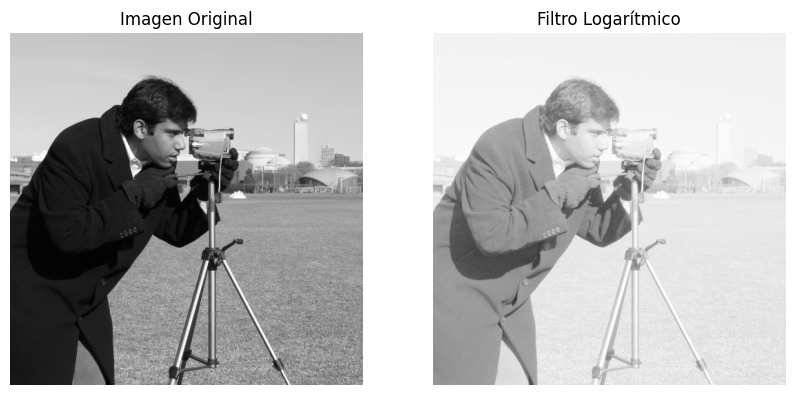

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# Cargar imagen y convertir a float
img = data.camera().astype(np.float64)

# Transformación logarítmica
c = 255 / np.log(1 + np.max(img))
log_img = c * np.log(1 + img)

# Ajustar valores al rango válido
log_img = np.clip(log_img, 0, 255)
log_img = log_img.astype(np.uint8)

# Mostrar resultados
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img.astype(np.uint8), cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(log_img, cmap='gray')
plt.title('Filtro Logarítmico')
plt.axis('off')

plt.show()

### Conclusión del filtro

El filtro logarítmico permite mejorar contraste y resaltar información en zonas oscuras de una imagen, siendo útil como técnica de realce más que como filtro de suavizado.

## d. Filtro de Caja Normalizado (Cuadro Normalizado)

### Definición

El filtro de caja normalizado es un filtro lineal que calcula el promedio de una vecindad, asignando pesos iguales a todos los píxeles del kernel, pero normalizados para que la suma de los pesos sea 1.

Se usa para reducir ruido y suavizar imágenes.

### Fórmula Matemática

**Kernel 3x3:**

$$\frac{1}{9} \begin{bmatrix} 1 & 1 & 1 \\ 1 & 1 & 1 \\ 1 & 1 & 1 \end{bmatrix}$$

**Expresión general:**

$$g(x,y) = \sum_{i} \sum_{j} K(i,j) f(x+i, y+j)$$

**Donde:**
* $K(i, j)$: kernel normalizado
* $f(x, y)$: imagen original
* $g(x, y)$: imagen filtrada

### Ejemplo Manual (una iteración)
Supongamos esta región:

$$\begin{bmatrix} 40 & 42 & 43 \\ 41 & 100 & 44 \\ 42 & 43 & 41 \end{bmatrix}$$

Calculamos el promedio:

$$\frac{40 + 42 + 43 + 41 + 100 + 44 + 42 + 43 + 41}{9}$$

$$\frac{436}{9} = 48.44$$

Aproximando:

$$48$$

Entonces:

$$100 \rightarrow 48$$

### Explicación del ejemplo
El valor central **100** genera una variación abrupta.
El filtro lo reemplaza por un valor promedio más coherente con sus vecinos, produciendo una región más suave.

---

### Ventajas y Desventajas

**Ventajas:**
* Fácil de implementar.
* Bajo costo computacional.
* Reduce ruido moderado.
* Buen filtro básico de suavizado.

**Desventajas:**
* Difumina bordes.
* Puede perder detalles finos.
* Todos los píxeles tienen la misma importancia.

---

### ¿Qué hace visualmente en la imagen?

**Antes:**
* Más cambios bruscos entre píxeles.

**Después:**
* Transiciones más suaves.
* Menos ruido.
* Imagen ligeramente desenfocada.

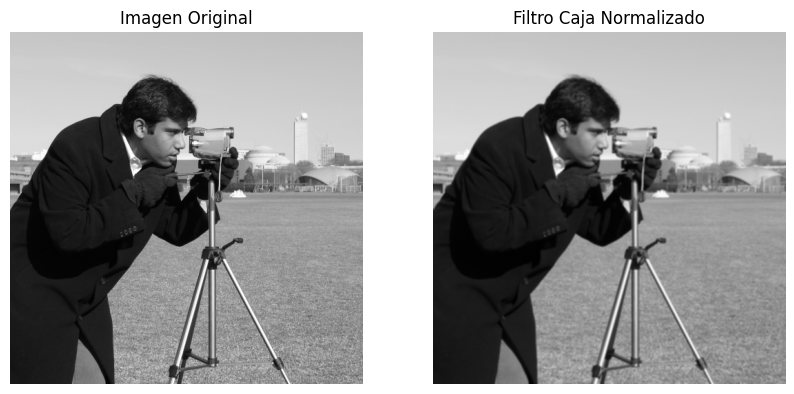

In [4]:
import cv2
import matplotlib.pyplot as plt
from skimage import data

img = data.camera()

# Filtro de caja normalizado
box = cv2.boxFilter(img,-1,(3,3),normalize=True)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(box,cmap='gray')
plt.title('Filtro Caja Normalizado')
plt.axis('off')

plt.show()

### Conclusión del filtro

El filtro de caja normalizado es una técnica sencilla de suavizado que reduce ruido y variaciones locales mediante promedios, aunque puede generar desenfoque y pérdida de bordes.

## e. Filtro Gaussiano

### Definición

El filtro gaussiano es un filtro lineal de suavizado basado en la distribución gaussiana (campana de Gauss), utilizado para reducir ruido y suavizar imágenes conservando mejor los bordes que un filtro promedio.

### Fórmula Matemática

**Función Gaussiana:**

$$G(x, y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2 + y^2}{2\sigma^2}}$$

**Donde:**
* $\sigma$: desviación estándar.
* Controla el nivel de suavizado.

**Un kernel gaussiano típico 3x3:**

$$\frac{1}{16} \begin{bmatrix} 1 & 2 & 1 \\ 2 & 4 & 2 \\ 1 & 2 & 1 \end{bmatrix}$$

### Fórmula Matemática

**Función Gaussiana:**

$$G(x, y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2 + y^2}{2\sigma^2}}$$

**Donde:**
* $\sigma$: desviación estándar.
* Controla el nivel de suavizado.

**Un kernel gaussiano típico 3x3:**

$$\frac{1}{16} \begin{bmatrix} 1 & 2 & 1 \\ 2 & 4 & 2 \\ 1 & 2 & 1 \end{bmatrix}$$

### Ejemplo Manual (una iteración)
Supongamos esta región:

$$\begin{bmatrix} 50 & 52 & 51 \\ 53 & 100 & 54 \\ 52 & 53 & 51 \end{bmatrix}$$

Aplicamos el kernel:

$$\frac{1}{16} [(1)(50) + (2)(52) + (1)(51) + (2)(53) + (4)(100) + (2)(54) + (1)(52) + (2)(53) + (1)(51)]$$

Calculamos:

$$\frac{1}{16} (50 + 104 + 51 + 106 + 400 + 108 + 52 + 106 + 51)$$

$$\frac{1028}{16} = 64.25$$

Aproximando:

$$64$$

Entonces:

$$100 \rightarrow 64$$

### Explicación del ejemplo
Aunque el píxel central tiene un valor alto, el filtro gaussiano le da más peso a los píxeles cercanos y menos a los lejanos.
Esto suaviza la región pero preserva mejor la estructura y los bordes comparado con un promedio simple.

---

### Ventajas y Desventajas

**Ventajas:**
* Reduce ruido eficazmente.
* Conserva mejor los bordes que el filtro de media.
* Suavizado más natural (basado en la distribución normal).
* Muy usado como preprocesamiento en visión artificial.

**Desventajas:**
* Puede generar algo de desenfoque.
* Puede perder detalles finos.
* Más costoso computacionalmente que el filtro promedio.
* Requiere elegir correctamente el valor de $\sigma$ (sigma).

---

### ¿Qué hace visualmente en la imagen?

**Antes:**
* Ruido y cambios bruscos de intensidad.

**Después:**
* Suavizado más natural y orgánico.
* Reducción notable del ruido.
* Menor distorsión de bordes en comparación con el filtro de caja.

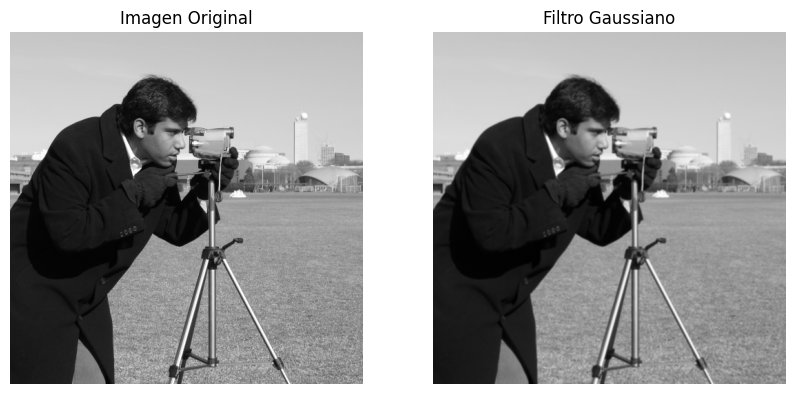

In [5]:
import cv2
import matplotlib.pyplot as plt
from skimage import data

img = data.camera()

# Filtro Gaussiano
gauss = cv2.GaussianBlur(img,(3,3),0)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gauss,cmap='gray')
plt.title('Filtro Gaussiano')
plt.axis('off')

plt.show()

### Conclusión del filtro

El filtro gaussiano es una técnica de suavizado más robusta que el promedio simple, ya que reduce ruido de manera eficiente y conserva mejor las estructuras importantes de la imagen.

## f. Filtro Laplace

### Definición

El filtro Laplace es un filtro basado en la segunda derivada que detecta regiones donde la intensidad cambia rápidamente, resaltando contornos y bordes.

Se usa para realce y detección de bordes.

### Fórmula Matemática

**Operador Laplaciano:**

$$\nabla^2 f = \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partial y^2}$$

**Forma discreta común (kernel 3x3):**

$$\begin{bmatrix} 0 & -1 & 0 \\ -1 & 4 & -1 \\ 0 & -1 & 0 \end{bmatrix}$$

---

### Expresión general

$$g(x,y) = \sum_{i} \sum_{j} K(i,j) f(x + i, y + j)$$

**Donde:**
* $K(i, j)$: kernel Laplaciano
* $f(x, y)$: imagen original
* $g(x, y)$: imagen filtrada

### Ejemplo Manual (una iteración)
Usaremos la siguiente vecindad:

$$\begin{bmatrix} 20 & 20 & 20 \\ 20 & 100 & 20 \\ 20 & 20 & 20 \end{bmatrix}$$

Aplicando el kernel:

$$(4)(100) - (20 + 20 + 20 + 20)$$
$$400 - 80 = 320$$

Resultado:

$$100 \rightarrow 320$$

### Explicación del ejemplo
El píxel central tiene un cambio brusco frente a sus vecinos. El filtro **Laplaciano** resalta esa variación produciendo un valor alto, lo que indica la presencia de un borde o una transición fuerte de intensidad.

---

### Ventajas y Desventajas

**Ventajas:**
* Muy bueno detectando bordes de forma omnidireccional.
* Resalta cambios bruscos de intensidad de manera eficiente.
* Fácil implementación mediante convolución.
* Útil para el realce de detalles.

**Desventajas:**
* Muy sensible al ruido (puede amplificarlo).
* Puede detectar bordes falsos si la imagen no está limpia.
* No indica la dirección del borde.
* Normalmente requiere un suavizado previo (como un filtro Gaussiano).

---

### ¿Qué hace visualmente en la imagen?

**Antes:**
* Los bordes están mezclados con las regiones normales de la imagen.

**Después:**
* Los contornos aparecen resaltados sobre un fondo oscuro.
* Los detalles finos se vuelven más notorios.
* Las zonas homogéneas (donde no hay cambios) casi desaparecen o se vuelven negras.

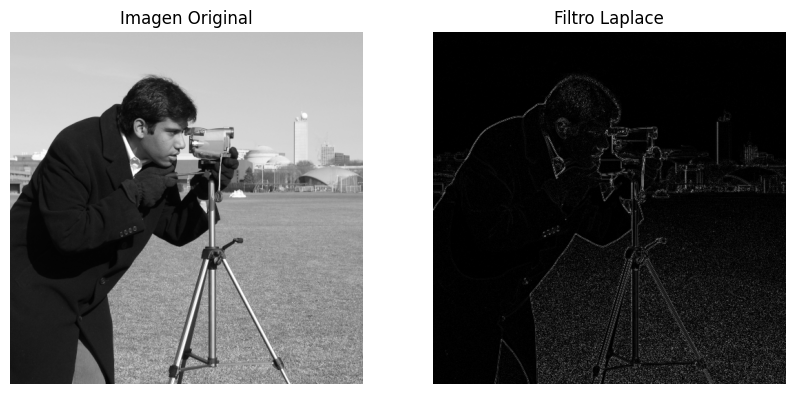

In [6]:
import cv2
import matplotlib.pyplot as plt
from skimage import data

img = data.camera()

laplace = cv2.Laplacian(img,cv2.CV_64F)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(abs(laplace),cmap='gray')
plt.title('Filtro Laplace')
plt.axis('off')

plt.show()

### Conclusión del filtro

El filtro Laplace es una técnica importante para detección de bordes y realce de detalles, aunque suele combinarse con suavizado previo debido a su sensibilidad al ruido.

## g. Filtro Sobel

### Definición
El filtro Sobel es un operador de detección de bordes que calcula el gradiente de intensidad de una imagen en dos direcciones:

* **Horizontal ($G_x$):** Detecta bordes verticales.
* **Vertical ($G_y$):** Detecta bordes horizontales.

Con esto permite detectar cambios bruscos de intensidad asociados a bordes en la imagen.

### Fórmula Matemática

**Máscara Sobel en x:**

$$G_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}$$

**Máscara Sobel en y:**

$$G_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}$$

**Magnitud del gradiente:**

$$G = \sqrt{G_x^2 + G_y^2}$$

**A veces se aproxima como:**

$$G = |G_x| + |G_y|$$

### Ejemplo Manual (una iteración)
Supongamos una región donde existe un **borde vertical**:

$$\begin{bmatrix} 10 & 10 & 100 \\ 10 & 10 & 100 \\ 10 & 10 & 100 \end{bmatrix}$$

#### 1. Calculamos $G_x$ (Gradiente Horizontal)
Usamos la máscara $G_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}$:

$$G_x = (-1)(10) + (0)(10) + (1)(100) + (-2)(10) + (0)(10) + (2)(100) + (-1)(10) + (0)(10) + (1)(100)$$
$$G_x = -10 + 100 - 20 + 200 - 10 + 100 = 360$$

#### 2. Calculamos $G_y$ (Gradiente Vertical)
Usamos la máscara $G_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}$:

$$G_y = (-1)(10) + (-2)(10) + (-1)(100) + (0)(10) + (0)(10) + (0)(100) + (1)(10) + (2)(10) + (1)(100)$$
$$G_y = (-130) + (0) + (130) = 0$$

#### 3. Magnitud del borde ($G$)
$$G = \sqrt{G_x^2 + G_y^2} = \sqrt{360^2 + 0^2} = 360$$

---

### ¿Qué significa ese 360?
Este valor es la **respuesta del gradiente**, no un nivel final de gris directo. Como puede ser mayor que 255, para visualizarlo se normaliza.
* **Usando clipping:** $360 \rightarrow 255$ (blanco puro).

### Explicación del ejemplo
* Como existe un cambio fuerte de intensidad entre 10 y 100, Sobel responde con un gradiente alto.
* Dado que $G_x \neq 0$ y $G_y = 0$, detectamos un **borde puramente vertical**.
* Sobel no solo detecta bordes, también permite conocer la **orientación** del mismo mediante el ángulo del gradiente.

### Ventajas y Desventajas (Filtro Sobel)

**Ventajas:**
* Detecta bordes de manera eficaz mediante el cálculo del gradiente.
* Identifica la **dirección** del borde (orientación).
* Reduce algo de sensibilidad al ruido gracias al peso central en sus máscaras.
* Fácil implementación computacional.

**Desventajas:**
* Puede detectar bordes "gruesos" que requieren adelgazamiento posterior.
* Sigue siendo sensible al ruido si no se aplica un suavizado previo (como Gaussiano).
* No produce bordes tan precisos como métodos más avanzados.
* Requiere normalización de los valores para poder visualizar la imagen correctamente.

---

### ¿Qué hace visualmente en la imagen?

**Antes:**
* Los bordes están mezclados con las intensidades normales de los objetos.

**Después:**
* Los **contornos aparecen resaltados** (blancos sobre fondo negro).
* Se destacan claramente las transiciones de color o iluminación.
* Permite separar visualmente las componentes horizontales y verticales del gradiente.

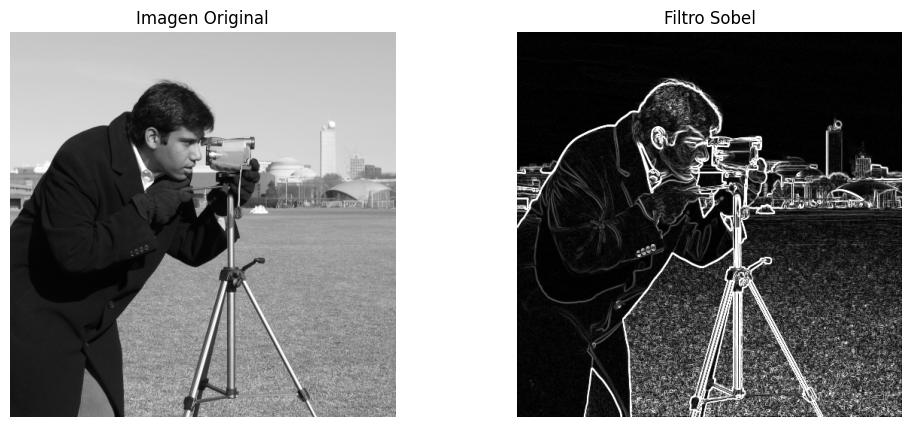

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

img = data.camera()

# Sobel X y Y
sobelx = cv2.Sobel(img,cv2.CV_64F,1,0,ksize=3)
sobely = cv2.Sobel(img,cv2.CV_64F,0,1,ksize=3)

# Magnitud del gradiente
magnitud = np.sqrt(sobelx**2 + sobely**2)
magnitud = cv2.convertScaleAbs(magnitud)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(magnitud,cmap='gray')
plt.title('Filtro Sobel')
plt.axis('off')

plt.show()

### Conclusión del filtro

El filtro Sobel es una técnica clásica para detección de bordes mediante gradientes, permitiendo identificar tanto la presencia como la dirección de los bordes en una imagen.

## h. Filtro Canny

### Definición

El filtro de Canny es un detector de bordes que combina suavizado, cálculo de gradiente y técnicas de refinamiento para obtener bordes delgados, continuos y bien definidos.

### Etapas del algoritmo (Detección de bordes Canny)

#### 1. Suavizado (Filtro Gaussiano)
Se aplica un filtro gaussiano para eliminar el ruido, ya que el ruido puede ser interpretado erróneamente como bordes.
$$I_s = G * I$$

#### 2. Cálculo del gradiente (Sobel)
Se utilizan los operadores de Sobel para obtener la intensidad y dirección de los cambios:
* **Magnitud:** $G = \sqrt{G_x^2 + G_y^2}$
* **Dirección:** $\theta = \tan^{-1}(G_y / G_x)$



#### 3. Supresión de no máximos
Se analizan los píxeles en la dirección del gradiente y se eliminan aquellos que no sean máximos locales.
* **Resultado:** Esto hace que los bordes sean delgados, con un ancho de exactamente **1 píxel**.

#### 4. Umbralización con histéresis
Se utilizan dos umbrales para decidir qué es realmente un borde:
* **Umbral alto:** Define los bordes "fuertes" o seguros.
* **Umbral bajo:** Define bordes "débiles" o candidatos.

**Regla de decisión:**
1. Si un borde débil está **conectado** a uno fuerte $\rightarrow$ se conserva.
2. Si un borde débil está aislado $\rightarrow$ se elimina.

### Ejemplo Conceptual de Canny

Imagina que tras aplicar Sobel, tenemos esta matriz de **Magnitudes ($G$)** y todos los píxeles tienen una **Dirección ($\theta$) de 0°** (gradiente horizontal, borde vertical):

$$\text{Matriz de Magnitudes (G)} = \begin{bmatrix} 50 & 120 & 150 & 80 \\ 50 & 130 & 160 & 90 \\ 50 & 120 & 150 & 80 \end{bmatrix}$$

#### Paso 3: Supresión de no máximos (Non-Maximum Suppression)
Analizamos el píxel central (**160**). Como su dirección es $0^\circ$, lo comparamos con sus vecinos de la izquierda (**130**) y la derecha (**90**).

* **Pregunta:** ¿Es $160 > 130$ y $160 > 90$?
* **Respuesta:** Sí. El píxel se mantiene. Los vecinos (130 y 90) al no ser máximos, se convierten en **0**.

#### Paso 4: Umbralización con Histéresis
Definimos nuestros umbrales: **Alto = 140**, **Bajo = 70**.

1. El píxel **160** es mayor al umbral alto $\rightarrow$ Se marca como **Borde Fuerte (255)**.
2. El píxel **80** (si no hubiera sido eliminado en el paso anterior) es mayor al umbral bajo pero menor al alto $\rightarrow$ Sería **Borde Débil**. Solo se conservaría si estuviera tocando a un 255.

---

### Resultado Final (La Matriz Adelgazada)

Tras la iteración, la matriz de intensidades visuales que verías en Colab pasa de ser una mancha grisácea a una línea blanca perfecta de 1 píxel de ancho:

$$\text{Matriz Final (Canny)} = \begin{bmatrix} 0 & 0 & 255 & 0 \\ 0 & 0 & 255 & 0 \\ 0 & 0 & 255 & 0 \end{bmatrix}$$

### Explicación del ejemplo
El algoritmo de Canny no es solo un filtro, es un proceso inteligente de decisión:
1. **Elimina ruido primero:** Usa el suavizado gaussiano como escudo.
2. **Detecta bordes con gradiente:** Localiza dónde hay cambios (estilo Sobel).
3. **Elimina bordes falsos:** Mediante la supresión de no máximos, se queda solo con la "cima" del borde.
4. **Conserva solo los más relevantes:** La histéresis conecta los puntos importantes y descarta el ruido residual.

Por eso produce resultados mucho más limpios y profesionales que Sobel o Laplace.

---

### Ventajas y Desventajas

**Ventajas:**
* **Precisión extrema:** Detecta la ubicación real del borde.
* **Reducción de ruido:** Muy robusto gracias al paso inicial de suavizado.
* **Bordes delgados:** Genera líneas de 1 píxel de ancho (ideal para análisis de formas).
* **Doble umbral:** La histéresis permite recuperar bordes tenues que otros filtros perderían.
* **Estándar de la industria:** Es considerado uno de los mejores detectores clásicos.

**Desventajas:**
* **Costo computacional:** Es más lento debido a sus múltiples etapas.
* **Sensibilidad a parámetros:** Los resultados cambian mucho según los umbrales elegidos.
* **Complejidad:** Requiere más lógica de programación que un filtro simple.

---

### ¿Qué hace visualmente en la imagen?

**Antes:**
* Imagen original con bordes mezclados con ruido y texturas irrelevantes.

**Después:**
* **Bordes finos y definidos:** Como si alguien hubiera calcado la imagen con un tiralíneas.
* **Limpieza total:** Desaparece el ruido y las manchas de gradiente grueso.
* **Contornos claros:** Solo quedan las siluetas esenciales de los objetos.

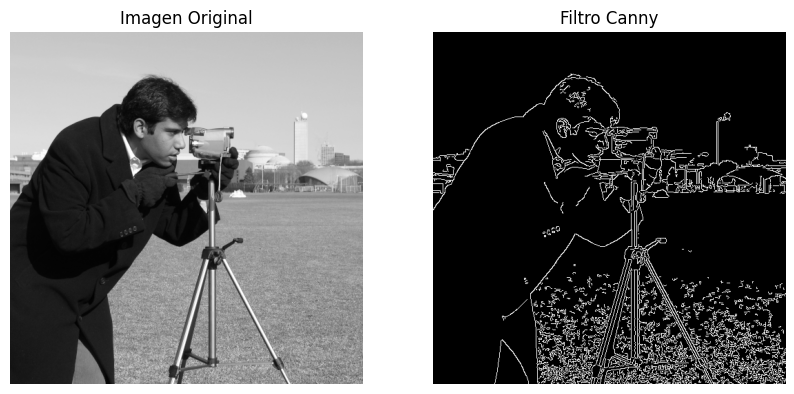

In [8]:
import cv2
import matplotlib.pyplot as plt
from skimage import data

img = data.camera()

# Filtro Canny
canny = cv2.Canny(img,100,200)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(canny,cmap='gray')
plt.title('Filtro Canny')
plt.axis('off')

plt.show()

### Conclusión del filtro

El filtro de Canny es uno de los métodos más completos y efectivos para detección de bordes, ya que combina múltiples etapas para producir resultados precisos, limpios y robustos frente al ruido.